In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import os
import glob
import sys
from tqdm import tqdm
import datetime
import gc
import numpy as np
import tensorflow as tf

In [46]:
config = {
    'project_path': 'drive/MyDrive/author-handwriting-recog',
    'dataset': 'complete_dataset_20260122-142244.tar.gz',
    'authors_range': range(50),
    'input_shape': (60, 53, 1),
    'embedding_dim': 256,
    'epochs': 15,
    'seed': 42
}

In [4]:
sys.path.insert(0, config['project_path'])

In [5]:
sys.path

['drive/MyDrive/author-handwriting-recog',
 '/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython']

In [6]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 17.3 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=708e196ec3925e035f7ee50403c683e7c6fca6e9be028af237fb7434a8e38c59
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [7]:
from src.io.exceptions import DeserializationError
from src.io.logging import LoggerFactory
from src import SelectiveDataLoader
from src.io import load

In [8]:
dataset_path = f"{config['project_path']}/data/datasets/{config['dataset']}"

In [9]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [10]:
logger = LoggerFactory.get_notebook_logger("code_1", log_dir=f"./logs_{current_time}")

In [11]:
!tar -xzf {dataset_path} -C ./

In [12]:
loader = SelectiveDataLoader(
        dataset_path="./complete_dataset_20260122-142244.zarr",
        load_fn=load
        )

05:21:19 - ZarrSerializer - INFO - Initialized with blosc compression (level 5)
05:21:19 - ZarrSerializer - INFO - ======================================================================
05:21:19 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
05:21:19 - ZarrSerializer - INFO - ======================================================================
05:21:19 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
05:21:19 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
05:21:19 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
05:21:19 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
05:21:19 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
05:21:19 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
05:21:19 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
05:21:19 - ZarrSerializer - INFO - ======================

In [14]:
from src.datasets import SubsetBuilder, PairGenerator, DataGenerator, TripletGenerator

In [15]:
subset_builder = SubsetBuilder(
    loader=loader,
)

In [16]:
subset = subset_builder.build(
    authors_range=config['authors_range'],
    show_progress_bar=True,
)

05:21:35 - ZarrSerializer - INFO - ======================================================================
05:21:35 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
05:21:35 - ZarrSerializer - INFO - ======================================================================
05:21:35 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
05:21:35 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
05:21:35 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
05:21:35 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
05:21:35 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
05:21:35 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
05:21:35 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
05:21:35 - ZarrSerializer - INFO - ======================================================================
05:21:35 - ZarrSerializer - INF

Loading train: 100%|██████████| 50/50 [00:14<00:00,  3.42it/s]


05:21:52 - ZarrSerializer - INFO - ======================================================================
05:21:52 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
05:21:52 - ZarrSerializer - INFO - ======================================================================
05:21:52 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
05:21:52 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
05:21:52 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
05:21:52 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
05:21:52 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
05:21:52 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
05:21:52 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
05:21:52 - ZarrSerializer - INFO - ======================================================================
05:21:52 - ZarrSerializer - INF

Loading validation: 100%|██████████| 50/50 [00:02<00:00, 21.44it/s]


05:21:55 - ZarrSerializer - INFO - ======================================================================
05:21:55 - ZarrSerializer - INFO - Loading Zarr dataset: complete_dataset_20260122-142244.zarr
05:21:55 - ZarrSerializer - INFO - ======================================================================
05:21:55 - ZarrSerializer - INFO - 📂 Loading partition (lazy mode)...
05:21:55 - ZarrSerializer - INFO -    ├─ train: 1,268,876 patches (~34851MB, lazy-loaded)
05:21:55 - ZarrSerializer - INFO -    ├─ validation: 206,216 patches (~5664MB, lazy-loaded)
05:21:55 - ZarrSerializer - INFO -    ├─ test: 51,067 patches (~1403MB, lazy-loaded)
05:21:55 - ZarrSerializer - INFO -    └─ Partition loaded (data not yet in memory)
05:21:55 - ZarrSerializer - INFO - 📂 Loading 'labels': (1526159,), 5.8MB
05:21:55 - ZarrSerializer - INFO - 📂 Loading metadata: 5 items
05:21:55 - ZarrSerializer - INFO - ======================================================================
05:21:55 - ZarrSerializer - INF

Loading test: 100%|██████████| 50/50 [00:00<00:00, 87.86it/s]


In [120]:
train_pair_gen = PairGenerator(
    data=subset.splits['train'],
    batch_size=64,
    shuffle=True,
    use_augmentation=True,
    seed=config['seed']
)

In [121]:
val_pair_gen = PairGenerator(
    data=subset.splits['validation'],
    batch_size=16,
    use_augmentation=False,
    shuffle=False,
)

In [122]:
test_pair_gen = PairGenerator(
    data=subset.splits['test'],
    batch_size=8,
    use_augmentation=False,
    shuffle=False,
)

In [123]:
len(train_pair_gen), len(val_pair_gen), len(test_pair_gen)

(2402, 1560, 776)

In [124]:
logger.info(f"Train samples: {train_pair_gen.num_patches}")
logger.info(f"Validation samples: {val_pair_gen.num_patches}")
logger.info(f"Test samples: {test_pair_gen.num_patches}")
logger.info(f"Ratio: {train_pair_gen.num_patches / val_pair_gen.num_patches:.2f}")

INFO - Train samples: 153701
INFO - Validation samples: 24954
INFO - Test samples: 6201
INFO - Ratio: 6.16


In [125]:
train_stats = train_pair_gen.get_statistics()
logger.info(f"Train samples: {train_stats["total_patches"]}")
logger.info(f"Avg patches per author: {train_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {train_stats["min_patches"]}")
logger.info(f"Max patches per author: {train_stats["max_patches"]}")

INFO - Train samples: 153701
INFO - Avg patches per author: 3074.02
INFO - Min patches per author: 792
INFO - Max patches per author: 3185


In [126]:
val_stats = val_pair_gen.get_statistics()
logger.info(f"Val samples: {val_stats["total_patches"]}")
logger.info(f"Avg patches per author: {val_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {val_stats["min_patches"]}")
logger.info(f"Max patches per author: {val_stats["max_patches"]}")

INFO - Val samples: 24954
INFO - Avg patches per author: 499.08
INFO - Min patches per author: 143
INFO - Max patches per author: 523


In [127]:
test_stats = test_pair_gen.get_statistics()
logger.info(f"Val samples: {test_stats["total_patches"]}")
logger.info(f"Avg patches per author: {test_stats["avg_patches_per_author"]:.2f}")
logger.info(f"Min patches per author: {test_stats["min_patches"]}")
logger.info(f"Max patches per author: {test_stats["max_patches"]}")

INFO - Val samples: 6201
INFO - Avg patches per author: 124.02
INFO - Min patches per author: 97
INFO - Max patches per author: 142


In [27]:
from src.models import (
    CNNBackbone,
    CNNTransformerBackbone,
    DeepCNNBackbone,
    build_siamese_model,
    build_embedding_model,
    ContrastiveLoss,
    BinaryCrossEntropyDistance,
    TripletLoss,
)
from src.models.training import ModelTrainer, get_default_callbacks
from src.models.evaluation import (
    ModelComparator,
    ModelEvaluator,
    plot_training_history,
    plot_comparison_metrics,
    plot_embeddings_tsne
)

In [128]:
backbone = DeepCNNBackbone()

In [129]:
cnn_trainer = ModelTrainer(
    backbone=backbone,
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

07:33:06 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
07:33:06 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
07:33:06 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [130]:
cnn_trainer.build(model_type="pair")

07:33:17 - siamese_cnn_trainer - INFO - Building models...
07:33:17 - siamese_cnn_trainer - INFO - Model built: siamese_model
07:33:17 - siamese_cnn_trainer - INFO - Total params: 3391296
07:33:17 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [131]:
cnn_trainer.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [132]:
cnn_trainer.siamese_model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [133]:
cnn_trainer.compile(loss=ContrastiveLoss(margin=1.0))

07:33:44 - siamese_cnn_trainer - INFO - Compiling model...
07:33:44 - siamese_cnn_trainer - INFO - Model compiled
07:33:44 - siamese_cnn_trainer - INFO -   - Optimizer: Adam
07:33:44 - siamese_cnn_trainer - INFO -   - Learning rate: 0.0001
07:33:44 - siamese_cnn_trainer - INFO -   - Loss: ContrastiveLoss
07:33:44 - siamese_cnn_trainer - INFO -   - Loss margin: 1.0


In [134]:
callbacks = get_default_callbacks(
    model_name="siamese_cnn",
    patience=4,
    reduce_lr_patience=2,
)

In [135]:
train_ds, train_steps = train_pair_gen.to_dataset()
val_ds, val_steps = val_pair_gen.to_dataset()

In [136]:
logger.info(f"Train steps: {train_steps}")
logger.info(f"Validation steps: {val_steps}")

INFO - Train steps: 2402
INFO - Validation steps: 1560


In [137]:
cnn_history = cnn_trainer.train(
    train_generator=train_ds,
    val_generator=val_ds,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=config['epochs'],
    callbacks=callbacks,
    verbose=1
)

07:34:24 - siamese_cnn_trainer - INFO - Starting training for 15 epochs...
07:34:24 - siamese_cnn_trainer - INFO -   - Train batches: 2402
07:34:24 - siamese_cnn_trainer - INFO -   - Val batches: 1560
Epoch 1/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.2515
Epoch 1: val_loss improved from inf to 0.23609, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 343s 138ms/step - loss: 0.2515 - val_loss: 0.2361 - learning_rate: 1.0000e-04
Epoch 2/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.2378
Epoch 2: val_loss did not improve from 0.23609
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 327s 136ms/step - loss: 0.2378 - val_loss: 0.2375 - learning_rate: 1.0000e-04
Epoch 3/15
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.2357
Epoch 3: val_loss improved from 0.23609 to 0.22924, saving model to checkpoints/siamese_cnn/best.keras
2402/2402 ━━━━━━━━━━━━━━━━━━━━ 328s 137ms/step - loss: 0.2357 - val_loss: 0.2292 - learning_rate: 1.0000e-04
Epoch 4/15

In [138]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title="Training Loss"):
    loss = history.history["loss"]
    val_loss = history.history.get("val_loss")

    plt.figure(figsize=(8, 5))
    plt.plot(loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(val_loss, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

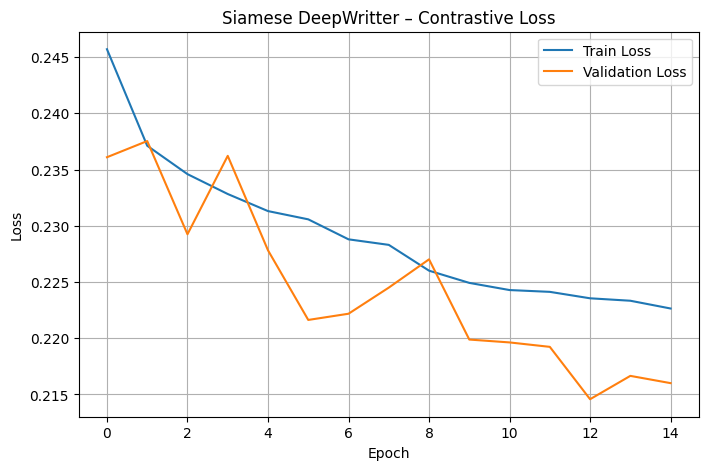

In [139]:
plot_training_loss(
    cnn_history,
    title="Siamese DeepWritter – Contrastive Loss"
)

In [140]:
cnn_trainer.save(f"./models/siamese_cnn_{current_time}.keras")

08:56:53 - siamese_cnn_trainer - INFO - Model saved to models/siamese_cnn_20260203-052013.keras


In [141]:
cnn_trainer_new = ModelTrainer(
    backbone=DeepCNNBackbone(),
    input_shape=config['input_shape'],
    embedding_dim=config['embedding_dim'],
    model_name="siamese_cnn",
    log_dir=f"./logs_{current_time}"
)

08:56:59 - siamese_cnn_trainer - INFO - Model trainer initialized: siamese_cnn
08:56:59 - siamese_cnn_trainer - INFO - Input shape: (60, 53, 1)
08:56:59 - siamese_cnn_trainer - INFO - Embedding dim: 256


In [142]:
cnn_trainer_new.build(model_type="pair")

08:57:04 - siamese_cnn_trainer - INFO - Building models...
08:57:04 - siamese_cnn_trainer - INFO - Model built: siamese_model
08:57:04 - siamese_cnn_trainer - INFO - Total params: 3391296
08:57:04 - siamese_cnn_trainer - INFO - Trainable params: 3388544


In [143]:
cnn_trainer_new.siamese_model.load_weights(
    f"./models/siamese_cnn_{current_time}.keras"
)

In [144]:
cnn_evaluator = ModelEvaluator(
    model=cnn_trainer_new.siamese_model,
    model_name="siamese_cnn",
    embedding_model=cnn_trainer_new.embedding_model,
    model_type="pair",
    log_dir=f"./logs_{current_time}"
)

In [145]:
cnn_evaluator.model.summary()

Model: "siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image1 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image2 (InputLayer) │ (None, 60, 53, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ siamese_cnn_embedd… │ (None, 256)       │  3,391,296 │ image1[0][0],     │
│ (Functional)        │                   │            │ image2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_4 (Stack)     │ (None, 2, 256)    │          0 │ siamese_cnn_embe… │
│                     │                   │            │ siamese_cnn_embe… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [146]:
cnn_evaluator.embedding_model.summary()

Model: "siamese_cnn_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 60, 53, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 60, 53, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 60, 53, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 60, 53, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 30, 26, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 30, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 30, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 15, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 15, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_22 (ReLU)                 │ (None, 15, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 7, 6, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_23 (ReLU)                 │ (None, 7, 6, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 7, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 7, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 7, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 256)            │        65,79

 Total params: 3,391,296 (12.94 MB)

 Trainable params: 3,388,544 (12.93 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [147]:
test_ds, test_steps = test_pair_gen.to_dataset()

In [151]:
test_results = cnn_evaluator.evaluate(
    test_generator=test_ds,
    steps=test_steps,
    distance_threshold=0.5446
)

09:01:49 - siamese_cnn_evaluator - INFO - Evaluating siamese_cnn...
09:02:50 - siamese_cnn_evaluator - INFO - Evaluation completed:
09:02:50 - siamese_cnn_evaluator - INFO -   - Accuracy:  0.7249
09:02:50 - siamese_cnn_evaluator - INFO -   - AUC:       0.8353
09:02:50 - siamese_cnn_evaluator - INFO -   - Precision: 0.6571
09:02:50 - siamese_cnn_evaluator - INFO -   - Recall:    0.9407
09:02:50 - siamese_cnn_evaluator - INFO -   - F1-Score:  0.7737


In [152]:
distances = test_results['distances']
y_true = test_results['y_true']

In [153]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, 1 - (distances / distances.max()))
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx] * distances.max()

logger.info(f"\nOptimal threshold: {optimal_threshold:.4f}")

INFO - 
Optimal threshold: 0.5346


INFO - Positive pairs - mean: 0.3242, std: 0.1282
INFO - Negative pairs - mean: 0.5479, std: 0.1802


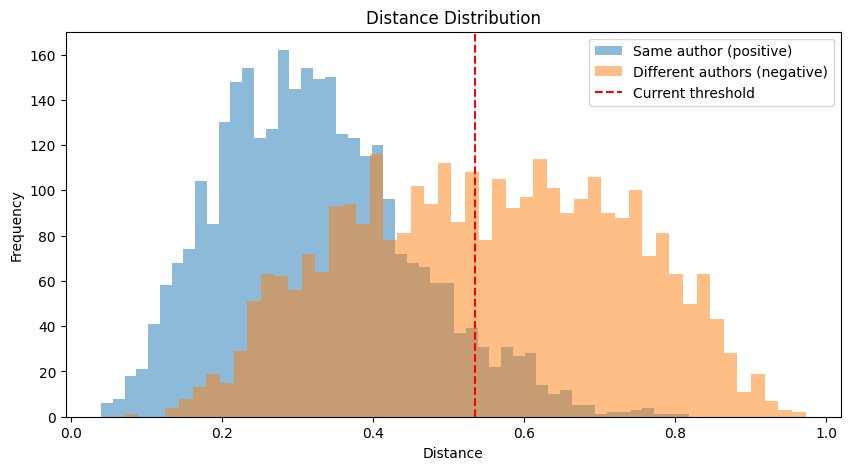

In [154]:
import matplotlib.pyplot as plt

pos_distances = distances[y_true == 1]
neg_distances = distances[y_true == 0]

logger.info(f"Positive pairs - mean: {pos_distances.mean():.4f}, std: {pos_distances.std():.4f}")
logger.info(f"Negative pairs - mean: {neg_distances.mean():.4f}, std: {neg_distances.std():.4f}")

# Plot histograma
plt.figure(figsize=(10, 5))
plt.hist(pos_distances, bins=50, alpha=0.5, label='Same author (positive)')
plt.hist(neg_distances, bins=50, alpha=0.5, label='Different authors (negative)')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label='Current threshold')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distance Distribution')
plt.show()

In [155]:
from src.datasets import DataGenerator

In [156]:
test_gen = DataGenerator(
    data=subset.splits['test'],
    batch_size=8,
    use_augmentation=False,
    shuffle=False
)

In [157]:
test_ds, test_steps = test_gen.to_dataset()

In [158]:
all_embeddings: list[np.ndarray] = []
all_author_ids: list[np.ndarray] = []

for X, y in test_ds.take(test_steps):
    emb = cnn_evaluator.embedding_model.predict(X, verbose=0)
    all_embeddings.append(emb)
    all_author_ids.append(y)

embeddings = np.concatenate(all_embeddings, axis=0)   # (N, D)
author_ids = np.concatenate(all_author_ids, axis=0)   # (N,)

In [159]:
from collections import defaultdict

def build_gallery(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
) -> dict[int, np.ndarray]:

    by_author: dict[int, list[np.ndarray]] = defaultdict(list)

    for emb, author_id in zip(embeddings, author_ids):
        by_author[int(author_id)].append(emb)

    gallery = {
        author_id: np.mean(np.stack(author_embs), axis=0)
        for author_id, author_embs in by_author.items()
    }

    return gallery

In [161]:
gallery = build_gallery(embeddings, author_ids)

In [162]:
def identify_author(
    author_embeddings: np.ndarray,
    gallery: dict[int, np.ndarray],
) -> dict[str, any]:

    scores: dict[int, float] = {}

    for author_id, gallery_emb in gallery.items():
        distances = np.linalg.norm(author_embeddings - gallery_emb, axis=1)
        scores[author_id] = float(distances.mean())

    pred_author = min(scores, key=scores.get)

    return {
        "pred_author_id": pred_author,
        "scores": scores,
        "mean_distance": scores[pred_author],
    }

In [163]:
from sklearn.metrics import accuracy_score

def evaluate_identification(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    gallery: dict[int, np.ndarray],
    min_patches: int = 3,
) -> dict[str, any]:

    y_true: list[int] = []
    y_pred: list[int] = []
    details: list[dict[str, any]] = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        author_embs = embeddings[idx]
        res = identify_author(author_embs, gallery)

        y_true.append(author_id)
        y_pred.append(res["pred_author_id"])

        details.append({
            "true_author_id": author_id,
            "pred_author_id": res["pred_author_id"],
            "correct": author_id == res["pred_author_id"],
            "mean_distance": res["mean_distance"],
        })

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "num_authors": len(y_true),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "details": details,
    }

In [164]:
import pandas as pd

def identification_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["true_author_id"] = df["true_author_id"].astype(int)
    df["pred_author_id"] = df["pred_author_id"].astype(int)
    df["correct"] = df["correct"].astype(bool)
    df["mean_distance"] = df["mean_distance"].astype(float)

    return df

In [165]:
def extract_identification_summary(res: dict) -> dict[str, float | int]:
    """
    Extract high-level identification metrics.
    """
    return {
        "accuracy": res["accuracy"],
        "num_authors": res["num_authors"],
    }

In [166]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    normalize: bool = True,
    max_classes: int = 30,
):
    unique_authors = np.unique(y_true)[:max_classes]
    mask = np.isin(y_true, unique_authors)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize="true" if normalize else None,
    )

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=True,
        xticks_rotation=90,
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [167]:
identification_results = evaluate_identification(
    embeddings,
    author_ids,
    gallery,
)
res = identification_results_to_df(identification_results)
summary = extract_identification_summary(identification_results)

In [168]:
logger.info(f"Identification summary: {summary}")

INFO - Identification summary: {'accuracy': 1.0, 'num_authors': 50}


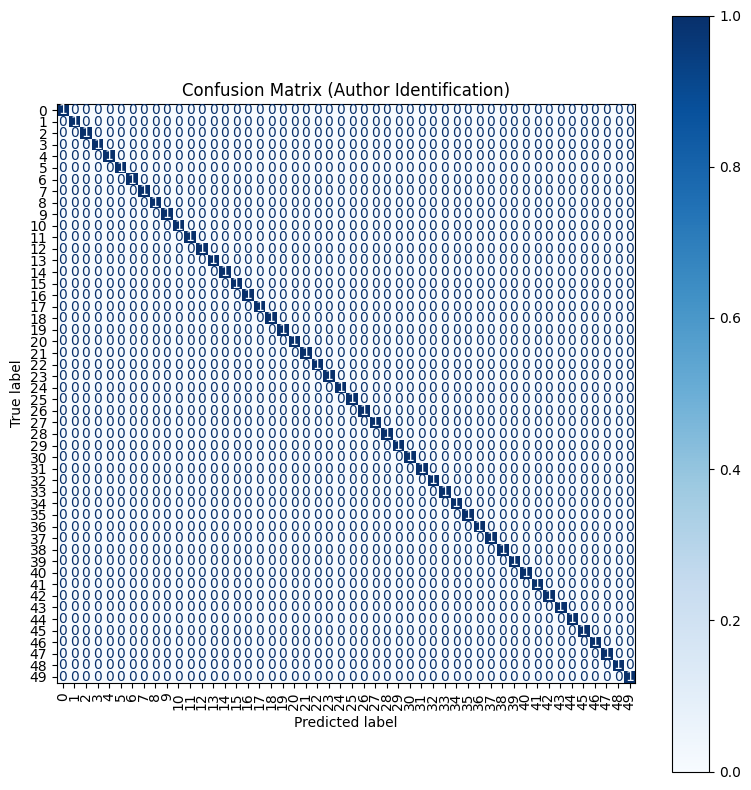

In [169]:
plot_confusion_matrix(
    identification_results["y_true"],
    identification_results["y_pred"],
    title="Confusion Matrix (Author Identification)",
    normalize=True,
    max_classes=50,
)

In [170]:
res

,true_author_id,pred_author_id,correct,mean_distance
0,0,0,True,0.146207
1,1,1,True,0.190979
2,2,2,True,0.129167
3,3,3,True,0.244358
4,4,4,True,0.208338
5,5,5,True,0.257553
6,6,6,True,0.220156
7,7,7,True,0.216979
8,8,8,True,0.154383
9,9,9,True,0.237647


In [184]:
def voting_for_author(
    embeddings: np.ndarray,
    distance_threshold: float,
) -> dict[str, any]:

    votes_same, votes_diff = 0, 0
    distances = []

    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            d = np.linalg.norm(embeddings[i] - embeddings[j])
            distances.append(d)

            if d < distance_threshold:
                votes_same += 1
            else:
                votes_diff += 1

    total = votes_same + votes_diff

    return {
        "votes_same": votes_same,
        "votes_diff": votes_diff,
        "confidence": votes_same / total if total > 0 else 0.0,
        "mean_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "num_pairs": total,
    }

In [174]:
def evaluate_voting(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    distance_threshold: float,
    min_patches: int = 3,
) -> dict[str, any]:

    details = []

    for author_id in np.unique(author_ids):
        idx = np.where(author_ids == author_id)[0]

        if len(idx) < min_patches:
            continue

        res = voting_for_author(
            embeddings[idx],
            distance_threshold,
        )

        details.append({
            "author_id": author_id,
            **res,
        })

    return {
        "num_authors": len(details),
        "details": details,
    }

In [192]:
import pandas as pd

def voting_results_to_df(res: dict) -> pd.DataFrame:
    """
    Convert identification results to a per-author DataFrame.
    """
    df = pd.DataFrame(res["details"])

    # Ensure proper dtypes
    df["author_id"] = df["author_id"].astype(int)
    df["votes_same"] = df["votes_same"].astype(int)
    df["votes_diff"] = df["votes_diff"].astype(int)
    df["confidence"] = df["confidence"].astype(float)
    df["mean_distance"] = df["mean_distance"].astype(float)
    df["std_distance"] = df["std_distance"].astype(float)
    df["num_pairs"] = df["num_pairs"].astype(int)

    return df

In [193]:
voting_results = evaluate_voting(
    embeddings,
    author_ids,
    distance_threshold=1.0
)
v_results = voting_results_to_df(voting_results)

In [194]:
v_results

,author_id,votes_same,votes_diff,confidence,mean_distance,std_distance,num_pairs
0,0,5778,0,1.0,0.206154,0.066624,5778
1,1,7503,0,1.0,0.269281,0.092993,7503
2,2,8515,0,1.0,0.186324,0.102508,8515
3,3,9180,0,1.0,0.343491,0.134166,9180
4,4,8001,0,1.0,0.292380,0.104826,8001
5,5,7503,0,1.0,0.365509,0.128171,7503
6,6,7626,0,1.0,0.309724,0.105554,7626
7,7,8128,0,1.0,0.306065,0.108307,8128
8,8,7140,0,1.0,0.218587,0.090311,7140
9,9,8128,0,1.0,0.334171,0.097966,8128


In [198]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def display_embedding_subset(
    embeddings: np.ndarray,
    author_ids: np.ndarray,
    num_authors: int,
    title: str,
    reducer,
    seed: int = 42,
) -> None:
    all_classes = np.unique(author_ids)
    rng = np.random.default_rng(seed)

    selected_classes = rng.choice(all_classes, size=num_authors, replace=False)

    mask = np.isin(author_ids, selected_classes)
    subset_embeddings = embeddings[mask]
    subset_author_ids = author_ids[mask]

    X_reduced = reducer.fit_transform(subset_embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=subset_author_ids, cmap='tab20', s=10)
    plt.colorbar(scatter)
    plt.title(f"{title} - {num_authors} Classes")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

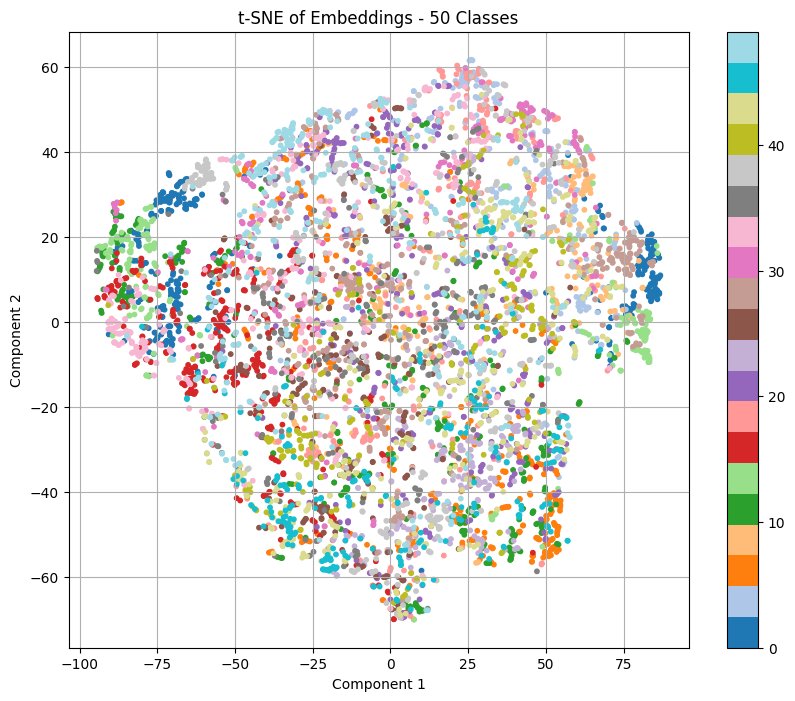

In [199]:
_reducer = TSNE(n_components=2, perplexity=30, random_state=config['seed'])
display_embedding_subset(
    embeddings,
    author_ids,
    num_authors=50,
    title="t-SNE of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


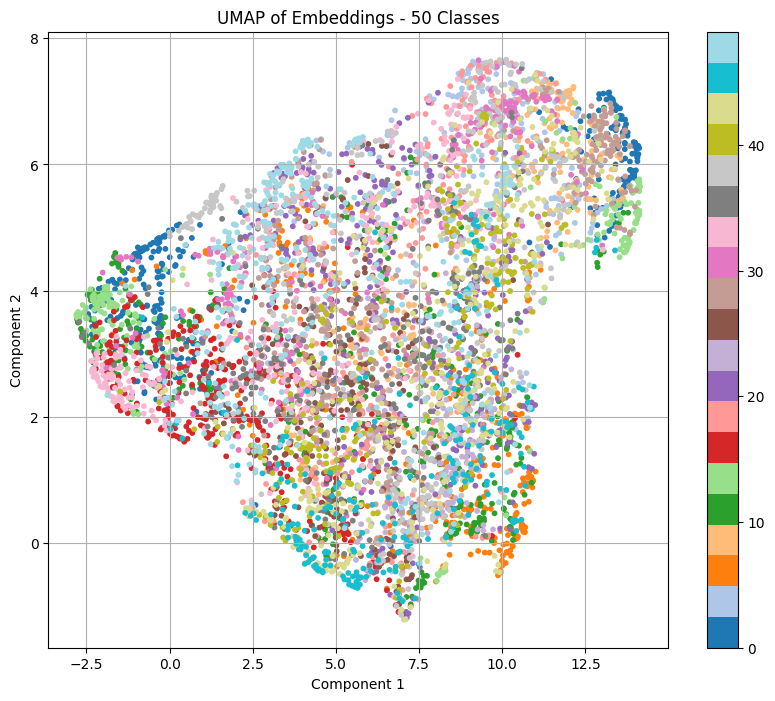

In [204]:
import umap.umap_ as umap

emb = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
_reducer = umap.UMAP(n_neighbors=20, min_dist=0.2, n_components=2, random_state=config['seed'])

display_embedding_subset(
    embeddings=emb,
    author_ids=author_ids,
    num_authors=50,
    title="UMAP of Embeddings",
    reducer=_reducer,
    seed=config['seed'],
)

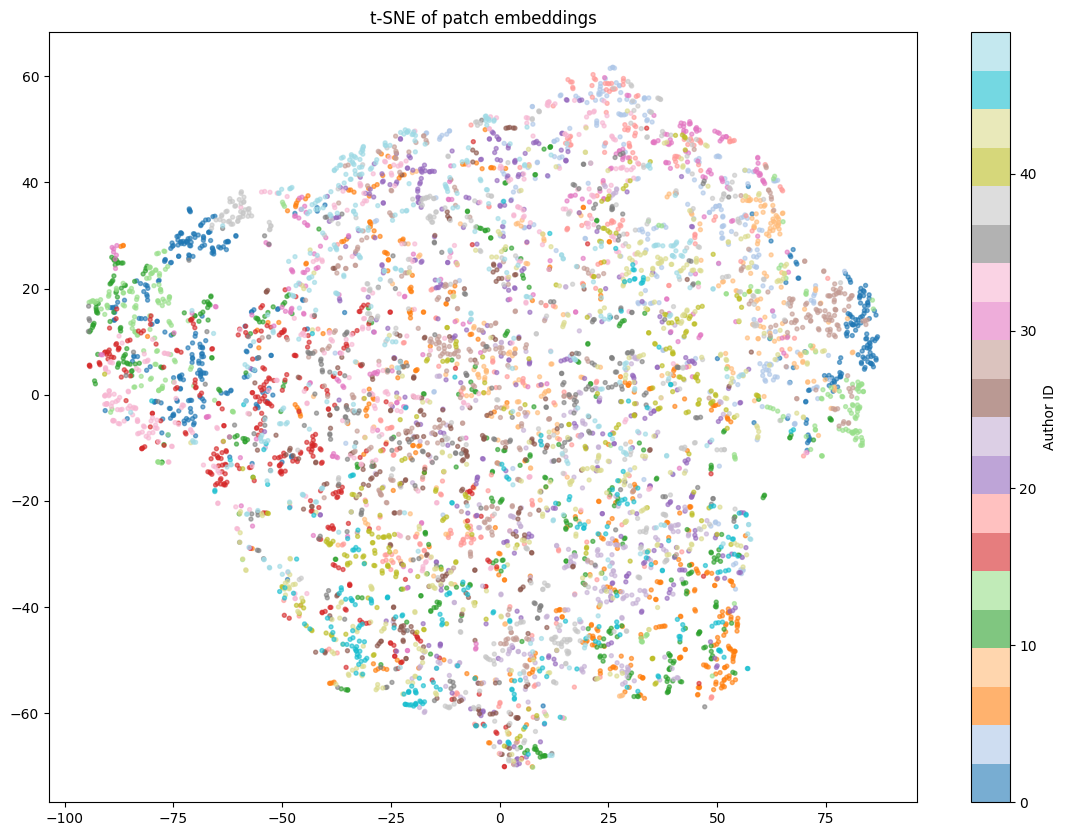

In [205]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
)

emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=author_ids,
    cmap="tab20",
    s=8,
    alpha=0.6,
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of patch embeddings")
plt.show()

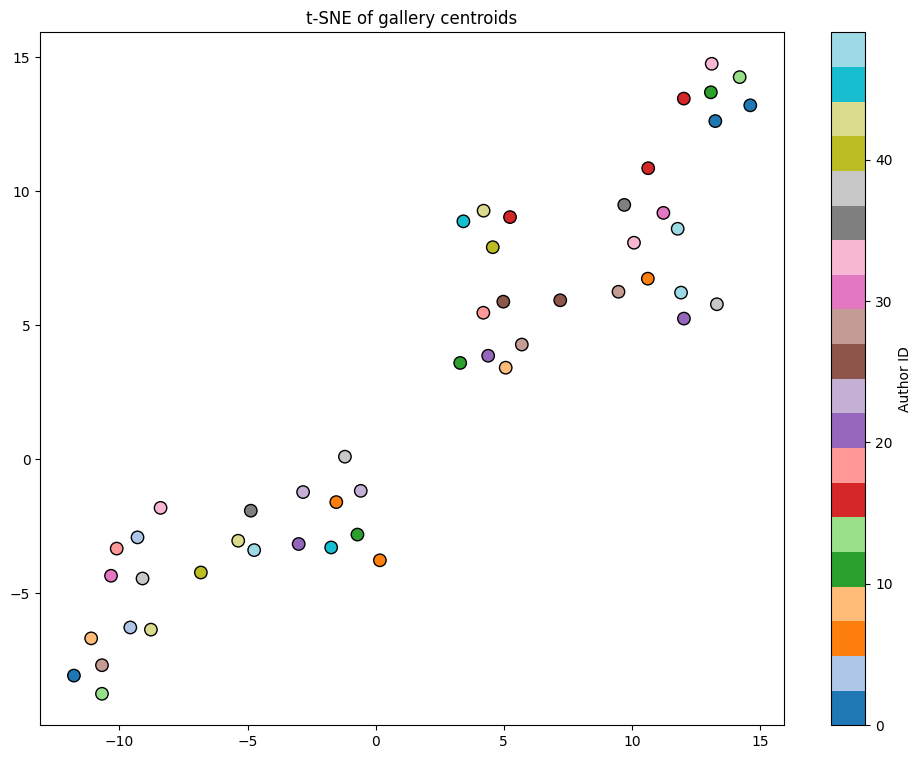

In [206]:
gallery_embeddings = np.stack(list(gallery.values()))
gallery_author_ids = np.array(list(gallery.keys()))

tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,
    random_state=42,
)

gallery_2d = tsne.fit_transform(gallery_embeddings)

plt.figure(figsize=(12, 9))
plt.scatter(
    gallery_2d[:, 0],
    gallery_2d[:, 1],
    c=gallery_author_ids,
    cmap="tab20",
    s=80,
    edgecolors="black",
)
plt.colorbar(label="Author ID")
plt.title("t-SNE of gallery centroids")
plt.show()